In [1]:
%load_ext autoreload
%autoreload 2

In [71]:
import os
import sys
current_dir = os.getcwd()  
source_dir  = os.path.join(current_dir, "source")
if source_dir not in sys.path:
    sys.path.insert(0, source_dir)

In [90]:
import numpy as np
from bao import BAOCosmology,BAOLikelihood
from cosmoprimo import Cosmology
from cosmoprimo.fiducial import DESI,AbacusSummit
from desilike.likelihoods.supernovae import Union3SNLikelihood,PantheonPlusSNLikelihood,DESY5SNLikelihood
from desilike import setup_logging
import matplotlib.pyplot as plt
from scipy.linalg import cho_factor, cho_solve
setup_logging()

In [75]:
from pantheonplus_compressed import CompressedPantheonPlusSNLikelihood

In [5]:
from desilike.install import Installer
installer = Installer(user=True)

In [6]:
installer(Union3SNLikelihood)
installer(PantheonPlusSNLikelihood)
installer(DESY5SNLikelihood)

In [56]:
installer.data_dir

<bound method Installer.data_dir of <desilike.install.Installer object at 0x7f09681bbc70>>

In [98]:
pp=PantheonPlusSNLikelihood(cosmo=DESI())

In [103]:
pp.calculate(-19.3)

In [104]:
pp.loglikelihood

Array(-1393.55167553, dtype=float64)

In [96]:
pp.loglikelihood-pp_compressed.loglikelihood

Array(-919.1956787, dtype=float64)

In [94]:
pp_compressed=CompressedPantheonPlusSNLikelihood(cosmo=AbacusSummit(1),compressed_fn='compressed_sn_data/pantheonplus_compressed.npz')

In [95]:
pp_compressed.calculate(-19.5)

In [97]:
pp_compressed.loglikelihood

Array(-475.4179644, dtype=float64)

In [80]:
pp_compressed.flatdata

array([16.95673784, 20.3223016 , 21.40751561, 22.05506929, 22.86136151,
       23.74437163, 25.25244637])

In [81]:
pp_compressed.flattheory

Array([36.39015416, 39.76819716, 40.84585167, 41.49803621, 42.32441397,
       43.23295637, 44.63818611], dtype=float64)

In [12]:
pp.covariance

array([[ 0.06543689, -0.00083541, -0.00124244, ..., -0.00077386,
        -0.00075876, -0.0006363 ],
       [-0.00083541,  0.06930601,  0.02413895, ...,  0.0002077 ,
         0.00156451,  0.00183639],
       [-0.00124244,  0.02413895,  0.0592691 , ...,  0.00091788,
         0.00204978,  0.00249542],
       ...,
       [-0.00077386,  0.0002077 ,  0.00091788, ...,  0.04157373,
         0.00490226,  0.00588703],
       [-0.00075876,  0.00156451,  0.00204978, ...,  0.00490226,
         0.06742823,  0.00875111],
       [-0.0006363 ,  0.00183639,  0.00249542, ...,  0.00588703,
         0.00875111,  0.04499005]])

In [16]:
pp.light_curve_params

{'CID': array(['2013E', '1999ac', '1999ac', ..., 'stone', 'wilson', 'colfax'],
       dtype='<U32'),
 'IDSURVEY': array([ 56.,  57.,  62., ..., 106., 106., 106.]),
 'zHD': array([0.01016, 0.01017, 0.01017, ..., 1.80119, 1.91165, 2.26137]),
 'zHDERR': array([0.00085, 0.00084, 0.00084, ..., 0.02014, 0.00263, 0.02018]),
 'zCMB': array([0.01042, 0.00979, 0.00979, ..., 1.80111, 1.9116 , 2.2613 ]),
 'zCMBERR': array([8.e-05, 2.e-05, 2.e-05, ..., 2.e-02, 1.e-03, 2.e-02]),
 'zHEL': array([0.00936, 0.00947, 0.00947, ..., 1.8    , 1.91401, 2.26   ]),
 'zHELERR': array([8.e-05, 2.e-05, 2.e-05, ..., 2.e-02, 1.e-03, 2.e-02]),
 'm_b_corr': array([13.5264, 13.6652, 13.7144, ..., 26.2335, 26.1703, 26.9298]),
 'm_b_corr_err_DIAG': array([0.3475  , 0.364224, 0.34081 , ..., 0.280685, 0.357624, 0.280011]),
 'MU_SH0ES': array([32.7794, 32.9182, 32.9674, ..., 45.4865, 45.4233, 46.1828]),
 'MU_SH0ES_ERR_DIAG': array([0.348547, 0.365223, 0.341878, ..., 0.281981, 0.358642, 0.281309]),
 'CEPH_DIST': array([-9.,

In [50]:
pp.light_curve_params['zHD'][pp.light_curve_params['zCMB']>0.01].shape

(1582,)

In [68]:
pp.flattheory

Array([33.29327894, 33.2954315 , 33.2954315 , ..., 45.73495188,
       45.8928745 , 46.33692995], dtype=float64)

In [67]:
pp.flatdata

array([13.52812039, 13.66670525, 13.71590525, ..., 26.23442268,
       26.16854065, 26.93071236])

In [42]:
pp.flatdiff

Array([0.50215856, 0.36572625, 0.31652625, ..., 0.2375292 , 0.46133384,
       0.14321759], dtype=float64)

In [46]:
pp.flatdiff.dot(pp.precision).dot(pp.flatdiff.T)/2

Array(1807.11000531, dtype=float64)

In [39]:
def rebin_SN(z, mu, cov, bins, *, drop_empty=True, include_rightmost=True,
             return_W=False):

    z = np.asarray(z, dtype=float)
    mu = np.asarray(mu, dtype=float)
    cov = np.asarray(cov, dtype=float)
    bins = np.asarray(bins, dtype=float)

    N = z.size
    if mu.size != N:
        raise ValueError(f"mu has length {mu.size} but z has length {N}")
    if cov.shape != (N, N):
        raise ValueError(f"cov has shape {cov.shape} but expected {(N, N)}")
    if bins.ndim != 1 or bins.size < 2:
        raise ValueError("bins must be 1D array of bin edges with length >= 2")

    nbins = bins.size - 1

    W = np.zeros((nbins, N), dtype=float)
    keep = np.ones(nbins, dtype=bool)

    for i in range(nbins):
        lo, hi = bins[i], bins[i + 1]

        if i == nbins - 1 and include_rightmost:
            mask = (z >= lo) & (z <= hi)
        else:
            mask = (z >= lo) & (z < hi)

        idx = np.where(mask)[0]
        if idx.size == 0:
            keep[i] = False
            continue

        C = cov[np.ix_(idx, idx)]

        ones = np.ones(idx.size, dtype=float)
        try:
            cf = cho_factor(C, lower=True, check_finite=False)
            x = cho_solve(cf, ones, check_finite=False)  # x = C^{-1} 1
        except Exception:
            x = np.linalg.lstsq(C, ones, rcond=None)[0]

        norm = float(ones @ x)  # 1^T C^{-1} 1
        if not np.isfinite(norm) or norm <= 0.0:
            keep[i] = False
            continue

        w = x / norm
        W[i, idx] = w

    if drop_empty:
        W = W[keep]
    else:
        pass

    mu_binned = W @ mu
    z_binned = W @ z
    cov_binned = W @ cov @ W.T

    cov_binned = 0.5 * (cov_binned + cov_binned.T)

    diag = np.diag(cov_binned)
    diag = np.where(diag < 0, 0.0, diag)
    err_binned = np.sqrt(diag)

    if return_W:
        return z_binned, mu_binned, err_binned, cov_binned, W
    return z_binned, mu_binned, err_binned, cov_binned

In [43]:
bins = np.array([0.01, 0.125, 0.235, 0.325, 0.425, 0.625, 0.825, 3])
z_binned, mu_binned, err_binned, cov_binned, W = rebin_SN(pp.light_curve_params['zHD'],
                                                       pp.flatdata,
                                                       pp.covariance,
                                                       bins,
                                                       return_W=True,
                                                       include_rightmost=False
                                                      )

In [46]:
z_b, mu_b, err_b, cov_b, W = rebin_SN(pp.light_curve_params['zHD'],
                                       pp.flatdata,
                                       pp.covariance,
                                       bins,
                                       return_W=True,
                                     )

np.savez("compressed_sn_data/pantheonplus_compressed.npz",
         W=W,
         z_full=pp.light_curve_params['zHD'],
         flatdata_binned0=mu_b,      # this is "flatdata" compressed with Mb=0
         cov_binned=cov_b,
         ones_binned=W @ np.ones_like(pp.light_curve_params['zHD']))

In [47]:
d=np.load('compressed_sn_data/pantheonplus_compressed.npz')

In [65]:
d['ones_binned']

array([1., 1., 1., 1., 1., 1., 1.])

In [63]:
row_sums = W.sum(axis=1)
print(np.max(np.abs(row_sums - 1.0)))

2.220446049250313e-16


In [64]:
nnz_per_row = (W != 0).sum(axis=1)
print(nnz_per_row.min(), nnz_per_row.max(), nnz_per_row.mean())

30 666 227.14285714285714


In [24]:
mu_binned

array([16.95673784, 20.3223016 , 21.40751561, 22.05506929, 22.86136151,
       23.74437163, 25.25244637])

In [25]:
err_binned

array([0.00709697, 0.0105842 , 0.0112151 , 0.01263273, 0.01562903,
       0.02564115, 0.05896081])

In [29]:
def plot_sn_rebin_with_residual(z, mu, cov, z_b, mu_b, cov_b, W,
                                title="SN: original vs rebinned", show=True):
    """
    Two-panel plot:
      Top: original mu(z) with errors + rebinned points
      Bottom: residual = mu_b - (W @ mu)  (should be ~0; diagnostic)

    Parameters
    ----------
    z, mu : (N,)
    cov : (N,N)
    z_b, mu_b : (nb,)
    cov_b : (nb,nb)
    W : (nb, N) compression matrix
    """
    z = np.asarray(z, float)
    mu = np.asarray(mu, float)
    cov = np.asarray(cov, float)

    z_b = np.asarray(z_b, float)
    mu_b = np.asarray(mu_b, float)
    cov_b = np.asarray(cov_b, float)
    W = np.asarray(W, float)

    err = np.sqrt(np.clip(np.diag(cov), 0.0, np.inf))
    err_b = np.sqrt(np.clip(np.diag(cov_b), 0.0, np.inf))

    # sort for nicer plotting
    s = np.argsort(z)
    sb = np.argsort(z_b)

    fig, (ax0, ax1) = plt.subplots(
        2, 1, figsize=(7, 6), sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
    )

    # --- Top panel ---
    ax0.errorbar(z[s], mu[s], yerr=err[s], fmt=".", ms=3, lw=0.8, alpha=0.5, label="Original")
    ax0.errorbar(z_b[sb], mu_b[sb], yerr=err_b[sb], fmt="o", ms=5, lw=1.2, label="Rebinned")
    ax0.set_ylabel(r"$\mu$")
    ax0.set_title(title)
    ax0.grid(True, alpha=0.3)
    ax0.legend()

    # --- Bottom panel: residual ---
    mu_b_from_W = W @ mu
    resid = mu_b - mu_b_from_W
    ax1.axhline(0.0, lw=1.0)
    ax1.plot(z_b[sb], resid[sb], "o", ms=4)
    ax1.set_xlabel("z")
    ax1.set_ylabel(r"$\Delta\mu$")
    ax1.grid(True, alpha=0.3)

    if show:
        plt.show()
    return fig, (ax0, ax1)

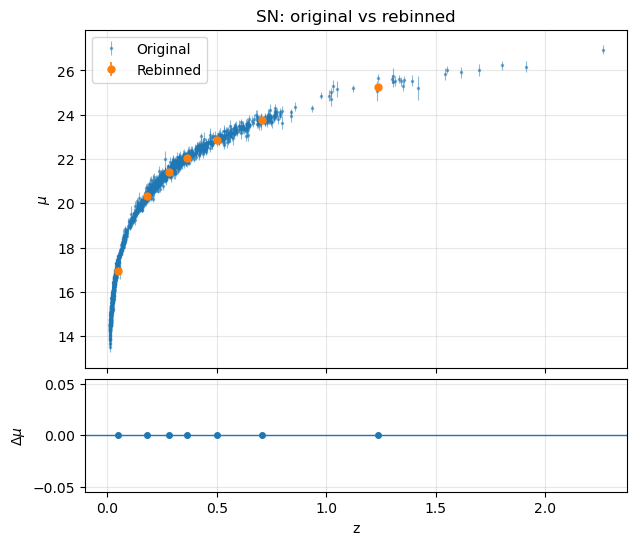

(<Figure size 700x600 with 2 Axes>,
 (<Axes: title={'center': 'SN: original vs rebinned'}, ylabel='$\\mu$'>,
  <Axes: xlabel='z', ylabel='$\\Delta\\mu$'>))

In [37]:
plot_sn_rebin_with_residual(pp.light_curve_params['zHD'],pp.flatdata,pp.covariance,
              z_binned, mu_binned,cov_binned,W         
             )

In [105]:
import numpy as np
from getdist import MCSamples, plots


def load_chain(fn, burn=0.0):
    data = np.loadtxt(fn)
    if data.ndim == 1:
        data = data[None, :]

    ncols = data.shape[1]
    if ncols < 4:
        raise ValueError(f"{fn}: expected >= 4 columns, got {ncols}")

    npar = ncols - 3
    samples = data[:, :npar]
    weights = data[:, npar]
    # logl = data[:, npar + 1]  # not needed for plotting
    # logp = data[:, npar + 2]

    # burn can be fraction (0<burn<1) or integer (>=1)
    if burn:
        if 0 < burn < 1:
            ib = int(burn * samples.shape[0])
        else:
            ib = int(burn)
        samples = samples[ib:]
        weights = weights[ib:]

    # normalize weights (GetDist is fine either way, but this helps numerical stability)
    wsum = np.sum(weights)
    if wsum > 0:
        weights = weights / wsum

    return samples, weights, npar


def default_names_labels(model, npar):
    if model.lower() == "w0wacdm":
        names = ["w0", "wa", "Omega_m", "omega_b", "h", "dM"]
        labels = [r"w_0", r"w_a", r"\Omega_m", r"\omega_b", r"h", r"\Delta M"]
    elif model.lower() == "lcdm":
        names = ["Omega_m", "omega_b", "h", "dM"]
        labels = [r"\Omega_m", r"\omega_b", r"h", r"\Delta M"]
    else:
        raise ValueError("Unknown model. Use w0waCDM or LCDM.")

    if len(names) != npar:
        raise ValueError(f"Model {model} expects {len(names)} params, but chain has {npar}. "
                         f"Use --names to override.")
    return names, labels


def make_mcsamples(samples, weights, names, labels, label):
    return MCSamples(
        samples=samples,
        weights=weights,
        names=names,
        labels=labels,
        label=label,
    )


def print_quick_stats(mc, names, title):
    stats = mc.getMargeStats()
    print(f"\n=== {title} ===")
    for n in names:
        p = stats.parWithName(n)
        mean = p.mean
        sd = p.sigma
        lo = p.limits[0].lower
        hi = p.limits[0].upper
        print(f"{n:10s}: mean={mean: .5f}  sigma={sd: .5f}  68%=[{lo: .5f}, {hi: .5f}]")
    print("================\n")


In [106]:
s1, w1, npar1 = load_chain('_out/original.txt')
s2, w2, npar2 = load_chain('_out/compressed.txt')

In [107]:
names, labels = default_names_labels('lcdm', npar1)

In [108]:
mc1 = make_mcsamples(s1, w1, names, labels, 'original')
mc2 = make_mcsamples(s2, w2, names, labels, 'compressed')

Removed no burn in
Removed no burn in


In [111]:
g = plots.get_subplot_plotter()
g.triangle_plot(
    [mc1, mc2],
    params=names,
    filled=False,
    legend_labels=['original', 'compressed'],
)
g.export('_out/compare.png')